# Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


In [2]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler


def pm_for_backend(bknd, opt_level, seed=42069):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    return pm


def prepare_dd_pm(backend, schedueling_method="alap", seq=[XGate(), XGate()]):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    target = backend.target
    pm = PassManager([ALAPScheduleAnalysis(target=target),PadDynamicalDecoupling(target=target, dd_sequence=seq)])
    return pm



def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def get_fidelity_for_circuit(ideal=dict, simulated=dict, no_dd_counts=dict, dd_counts=dict):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated, no_dd_counts, dd_counts]:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in [no_dd_counts, dd_counts]:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]

## Circuit generation and transpilation

In [3]:
## Prepare circuit dict
circuit_dict = {f"{i}":prepare_ghz(n_qubits=i) for i in range(7, 11)}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x715898887090>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7158c1fdb190>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x715897915a50>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x71589725b690>}

In [4]:
## Transpile circuit for torino backend
service = QiskitRuntimeService(name="qamp-2025")

torino = service.backend("ibm_torino")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(torino, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{i}":pm3.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

## Transpile for DD
pm_dd = prepare_dd_pm(torino) # args: backend, scheduelling_method, seq
isa_dd_dict = {f"{i}":pm_dd.run(isa_dict[f"{i}"]) for i in range(7, 11)}


print(isa_dict)
print(isa_dd_dict)


management.get:WARNING:2025-11-06 12:36:48,246: Loading saved account: qamp-2025


{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x715896743e10>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x71589674bd90>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x715896741790>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x715896896350>}
{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7158967065d0>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x715896722250>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7158967504d0>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x715896327950>}


In [5]:
isa_dict["7"].draw()

global phase: 5π/4
          ┌─────────┐┌────┐┌─────────┐                                        »
q_0 -> 45 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■──────────────────────────────────────»
          ├─────────┤├────┤└┬───────┬┘ │ ┌────┐┌─────────┐                    »
q_1 -> 46 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─■──────────────────»
          ├─────────┤├────┤ ├───────┤    └────┘└─────────┘ │ ┌────┐┌─────────┐»
q_2 -> 55 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────■─┤ √X ├┤ Rz(π/2) ├»
          ├─────────┤├────┤ ├───────┤                        └────┘└─────────┘»
q_3 -> 65 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├─────────────────────────────────────────»
          ├─────────┤├────┤ ├───────┤                                         »
q_4 -> 66 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├─────────────────────────────────────────»
          ├─────────┤├────┤ ├───────┤                                         »
q_5 -> 67 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├─────────────────────────────────────────»
          ├─────────┤├────┤ ├───────┤                                         »
q_6 -> 68 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├─────────────────────────────────────────»
          └─────────┘└────┘ └───────┘                                         »
  meas: 7/════════════════════════════════════════════════════════════════════»
                                                                              »
«                                                                         »
«q_0 -> 45 ───────────────────────────────────────────────────────────────»
«                                                                         »
«q_1 -> 46 ───────────────────────────────────────────────────────────────»
«                                                                         »
«q_2 -> 55 ─■─────────────────────────────────────────────────────────────»
«           │ ┌────┐┌─────────┐                                           »
«q_3 -> 65 ─■─┤ √X ├┤ Rz(π/2) ├─■─────────────────────────────────────────»
«             └────┘└─────────┘ │ ┌────┐┌─────────┐                       »
«q_4 -> 66 ─────────────────────■─┤ √X ├┤ Rz(π/2) ├─■─────────────────────»
«                                 └────┘└─────────┘ │ ┌────┐┌─────────┐   »
«q_5 -> 67 ─────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■─»
«                                                     └────┘└─────────┘ │ »
«q_6 -> 68 ─────────────────────────────────────────────────────────────■─»
«                                                                         »
«  meas: 7/═══════════════════════════════════════════════════════════════»
«                                                                         »
«                            ░ ┌─┐                  
«q_0 -> 45 ──────────────────░─┤M├──────────────────
«                            ░ └╥┘┌─┐               
«q_1 -> 46 ──────────────────░──╫─┤M├───────────────
«                            ░  ║ └╥┘┌─┐            
«q_2 -> 55 ──────────────────░──╫──╫─┤M├────────────
«                            ░  ║  ║ └╥┘┌─┐         
«q_3 -> 65 ──────────────────░──╫──╫──╫─┤M├─────────
«                            ░  ║  ║  ║ └╥┘┌─┐      
«q_4 -> 66 ──────────────────░──╫──╫──╫──╫─┤M├──────
«                            ░  ║  ║  ║  ║ └╥┘┌─┐   
«q_5 -> 67 ──────────────────░──╫──╫──╫──╫──╫─┤M├───
«          ┌────┐┌─────────┐ ░  ║  ║  ║  ║  ║ └╥┘┌─┐
«q_6 -> 68 ┤ √X ├┤ Rz(π/2) ├─░──╫──╫──╫──╫──╫──╫─┤M├
«          └────┘└─────────┘ ░  ║  ║  ║  ║  ║  ║ └╥┘
«  meas: 7/═════════════════════╩══╩══╩══╩══╩══╩══╩═
«                               0  1  2  3  4  5  6

In [6]:
isa_dd_dict["7"].draw(idle_wires=False)

global phase: 5π/4
           ┌─────────┐       ┌────┐  ┌─────────┐         ┌───────────────┐»
  q_45: ───┤ Rz(π/2) ├───────┤ √X ├──┤ Rz(π/2) ├────■────┤ Delay(33[dt]) ├»
           ├─────────┤       ├────┤  └┬───────┬┘    │    └─────┬────┬────┘»
  q_46: ───┤ Rz(π/2) ├───────┤ √X ├───┤ Rz(π) ├─────■──────────┤ √X ├─────»
        ┌──┴─────────┴──┐ ┌──┴────┴─┐ └─┬────┬┘ ┌───────┐      └────┘     »
  q_55: ┤ Delay(25[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────»
        ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                 »
  q_65: ┤ Delay(50[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────»
        ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                 »
  q_66: ┤ Delay(88[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────»
        ├───────────────┴┐├─────────┤   ├────┤  ├───────┤                 »
  q_67: ┤ Delay(113[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────»
        ├────────────────┤├─────────┤   ├────┤  ├───────┤                 »
  q_68: ┤ Delay(138[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────»
        └────────────────┘└─────────┘   └────┘  └───────┘                 »
meas: 7/══════════════════════════════════════════════════════════════════»
                                                                          »
«           ┌───┐   ┌───────────────┐      ┌───┐      ┌───────────────┐»
«  q_45: ───┤ X ├───┤ Delay(69[dt]) ├──────┤ X ├──────┤ Delay(33[dt]) ├»
«        ┌──┴───┴──┐└───────────────┘┌─────┴───┴─────┐└─────┬───┬─────┘»
«  q_46: ┤ Rz(π/2) ├────────■────────┤ Delay(27[dt]) ├──────┤ X ├──────»
«        └─────────┘        │        └─────┬────┬────┘   ┌──┴───┴──┐   »
«  q_55: ───────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───»
«                                          └────┘        └─────────┘   »
«  q_65: ──────────────────────────────────────────────────────────────»
«                                                                      »
«  q_66: ──────────────────────────────────────────────────────────────»
«                                                                      »
«  q_67: ──────────────────────────────────────────────────────────────»
«                                                                      »
«  q_68: ──────────────────────────────────────────────────────────────»
«                                                                      »
«meas: 7/══════════════════════════════════════════════════════════════»
«                                                                      »
«                                                                            »
«  q_45: ────────────────────────────────────────────────────────────────────»
«        ┌───────────────┐      ┌───┐      ┌───────────────┐                 »
«  q_46: ┤ Delay(56[dt]) ├──────┤ X ├──────┤ Delay(27[dt]) ├─────────────────»
«        └───────────────┘┌─────┴───┴─────┐└─────┬───┬─────┘┌───────────────┐»
«  q_55: ────────■────────┤ Delay(18[dt]) ├──────┤ X ├──────┤ Delay(36[dt]) ├»
«                │        └─────┬────┬────┘   ┌──┴───┴──┐   └───────────────┘»
«  q_65: ────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────»
«                               └────┘        └─────────┘           │        »
«  q_66: ───────────────────────────────────────────────────────────■────────»
«                                                                            »
«  q_67: ────────────────────────────────────────────────────────────────────»
«                                                                            »
«  q_68: ────────────────────────────────────────────────────────────────────»
«                                                                            »
«meas: 7/════════════════════════════════════════════════════════════════════»
«                                                                            »
«                                                                           »
«  q_45: ──────────────────

In [7]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()

noiseless_pub = [(isa_dict[f"{i}"]) for i in range(7, 11)]

noiseless_pub
with Batch(backend=noiseless_backend) as batch:
    noiseless_sampler = naked_sampler(mode=batch)
    noiseless_job = noiseless_sampler.run(noiseless_pub, shots=4096)
    noiseless_result = noiseless_job.result()




/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [8]:
simulated_counts = {f"{i+7}":noiseless_result[i].data.meas.get_counts() for i in range(0,4)}

In [ ]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{i}":[(isa_dict[f"{i}"]), (isa_dd_dict[f"{i}"])] for i in range(7, 11)}
pub_hardware_dict

{'7': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x715896743e10>,
 '8': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x71589674bd90>,
 '9': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x715896741790>,
 '10': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x715896896350>,
  <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x715896327950>]}

# Hardware Execution Cell. Do not run unless required

In [10]:
## Executing experiments with iterations = 3. Total circuit to run = 3*4 = 12
# hardware_job_dict = {f"{iter}":{f"{i}":execute_on_hardware(torino, pub_hardware_dict[f"{i}"]) for i in range(7, 11)} for iter in range(0, 3)}

Above are the job-ids of experiments. Used these to get the Result Objects. 

In [11]:
hardware_job_dict = {}
# Iteration 0
hardware_job_dict['0'] = {'7': 'd44ujo0oftds73c7rq1g',
 '8': 'd44ujogccj0s7387nq40',
 '9': 'd44ujp0ccj0s7387nq4g',
 '10': 'd44ujpgccj0s7387nq5g'}

In [12]:
# Iteration 1
hardware_job_dict['1'] = {'7': 'd44ujq0oftds73c7rq4g',
 '8': 'd44ujqgccj0s7387nq70',
 '9': 'd44ujr0oftds73c7rq60',
 '10': 'd44ujrjen7ps73bi8sk0'}

In [13]:
# Iteration 2
hardware_job_dict['2'] = {'7': 'd44ujs0ccj0s7387nqa0',
 '8': 'd44ujsooftds73c7rq8g',
 '9': 'd44ujtben7ps73bi8sm0',
 '10': 'd44ujtren7ps73bi8sn0'}

In [14]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-06 12:37:00,644: Loading saved account: qamp-2025


In [15]:

def store_data(service, job_dict, simulated):
    #           0         1       2        3          4                5                6             7                 8                               9    
    # Index iteration | job_id | Qubit | shots | ideal_counts | simulated_counts | no_dd_counts | dd_counts | hellinger_fidelity(ideal) | hellinger_fidelity(simulated)
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "ideal_counts", "simulated_counts", "no_dd_counts", "dd_counts", "hellinger_fidelity(ideal)", "hellinger_fidelity(simulated)"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
            shots = result[0].data.meas.num_shots
            data_list.append(shots)
            
            # 3 Ideal_counts
            ideal = {'0'*int(qubit):int(shots/2), '1'*int(qubit):int(shots/2)}
            data_list.append(ideal)
            
            # 4 Simulated_counts
            simulated_counts = simulated[qubit]
            data_list.append(simulated_counts)
            
            # 5 no_dd_counts
            no_dd_counts = result[0].data.meas.get_counts()
            data_list.append(no_dd_counts)
            
            # 6 dd_counts
            dd_counts = result[1].data.meas.get_counts()
            data_list.append(dd_counts)

            # 7 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
            data_list += get_fidelity_for_circuit(ideal, simulated_counts, no_dd_counts, dd_counts)

        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [16]:
experiment_results = store_data(service, hardware_job_dict, simulated_counts)

In [ ]:
## Save data to .csv

experiment_results.to_csv("GHZ-on-hardware.csv", index=False)


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d44ujo0oftds73c7rq1g,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'0000000': 1797, '1111000': 41, '1111111': 15...","{'0000000': 1730, '1111111': 1515, '0010000': ...","[0.9999227464122543, 0.8195695747736642, 0.791...","[0.8200063000983601, 0.7917661978506112]"
1,0,d44ujogccj0s7387nq40,8,4096,"{'00000000': 2048, '11111111': 2048}","{'00000000': 2014, '11111111': 2082}","{'00000000': 1775, '00000011': 52, '11111111':...","{'01000000': 8, '11111111': 1277, '00000000': ...","[0.9999310922823661, 0.7708756531076357, 0.717...","[0.7700506086115755, 0.7167837848960789]"
2,0,d44ujp0ccj0s7387nq4g,9,4096,"{'000000000': 2048, '111111111': 2048}","{'111111111': 2093, '000000000': 2003}","{'000000000': 1601, '111101000': 8, '000100000...","{'111111111': 1139, '000000000': 1468, '000100...","[0.9998792860224655, 0.6784728915027067, 0.633...","[0.6772970903953299, 0.6329716332959201]"
3,0,d44ujpgccj0s7387nq5g,10,4096,"{'0000000000': 2048, '1111111111': 2048}","{'0000000000': 2108, '1111111111': 1988}","{'0000000000': 1644, '1101111111': 32, '111111...","{'0001000000': 58, '0000000000': 1540, '000000...","[0.9997853772158692, 0.7121319062054805, 0.660...","[0.713267108823716, 0.6617718034533571]"
4,1,d44ujq0oftds73c7rq4g,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'1111111': 1547, '0000000': 1824, '1110111': ...","{'0000000': 1782, '1111111': 1538, '1110111': ...","[0.9999227464122543, 0.821606442405718, 0.8094...","[0.8221374553844653, 0.8099119971337146]"
5,1,d44ujqgccj0s7387nq70,8,4096,"{'00000000': 2048, '11111111': 2048}","{'00000000': 2014, '11111111': 2082}","{'00000000': 1806, '11111111': 1426, '11111110...","{'00000011': 48, '00000000': 1630, '11111011':...","[0.9999310922823661, 0.7863260681767733, 0.727...","[0.7855019807928726, 0.7266028373051353]"
6,1,d44ujr0oftds73c7rq60,9,4096,"{'000000000': 2048, '111111111': 2048}","{'111111111': 2093, '000000000': 2003}","{'000000000': 1609, '000000111': 107, '1111101...","{'111111110': 54, '111111111': 1188, '00000000...","[0.9998792860224655, 0.6934103921317256, 0.650...","[0.6923453468015274, 0.6494640073469168]"
7,1,d44ujrjen7ps73bi8sk0,10,4096,"{'0000000000': 2048, '1111111111': 2048}","{'0000000000': 2108, '1111111111': 1988}","{'0000000001': 129, '1111111111': 1246, '00000...","{'1111111111': 1183, '1111101111': 90, '100000...","[0.9997853772158692, 0.7051707171092455, 0.653...","[0.7064899880465467, 0.6541972763033402]"
8,2,d44ujs0ccj0s7387nqa0,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'0000000': 1794, '1111111': 1549, '0111111': ...","{'0000000': 1757, '1111111': 1506, '1000000': ...","[0.9999227464122543, 0.81506472142881, 0.79545...","[0.8155275524989095, 0.7959278902421464]"
9,2,d44ujsooftds73c7rq8g,8,4096,"{'00000000': 2048, '11111111': 2048}","{'00000000': 2014, '11111111': 2082}","{'00000000': 1764, '11111111': 1385, '11110111...","{'00000000': 1609, '01000000': 4, '11111111': ...","[0.9999310922823661, 0.7660045658051721, 0.706...","[0.7651839092725087, 0.7059609508404507]"


## Load saved dataset. Run from here to analyze the data.


In [8]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [9]:

df = pd.read_csv("GHZ-on-hardware.csv")

df.ideal_counts = df.ideal_counts.apply(ast.literal_eval)
df.simulated_counts = df.simulated_counts.apply(ast.literal_eval)
df.no_dd_counts = df.no_dd_counts.apply(ast.literal_eval)
df.dd_counts = df.dd_counts.apply(ast.literal_eval)
df["hellinger_fidelity(ideal)"] = df["hellinger_fidelity(ideal)"].apply(ast.literal_eval)
df["hellinger_fidelity(simulated)"] = df["hellinger_fidelity(simulated)"].apply(ast.literal_eval)
df


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d44ujo0oftds73c7rq1g,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'0000000': 1797, '1111000': 41, '1111111': 15...","{'0000000': 1730, '1111111': 1515, '0010000': ...","[0.9999227464122543, 0.8195695747736642, 0.791...","[0.8200063000983601, 0.7917661978506112]"
1,0,d44ujogccj0s7387nq40,8,4096,"{'00000000': 2048, '11111111': 2048}","{'00000000': 2014, '11111111': 2082}","{'00000000': 1775, '00000011': 52, '11111111':...","{'01000000': 8, '11111111': 1277, '00000000': ...","[0.9999310922823661, 0.7708756531076357, 0.717...","[0.7700506086115755, 0.7167837848960789]"
2,0,d44ujp0ccj0s7387nq4g,9,4096,"{'000000000': 2048, '111111111': 2048}","{'111111111': 2093, '000000000': 2003}","{'000000000': 1601, '111101000': 8, '000100000...","{'111111111': 1139, '000000000': 1468, '000100...","[0.9998792860224655, 0.6784728915027067, 0.633...","[0.6772970903953299, 0.6329716332959201]"
3,0,d44ujpgccj0s7387nq5g,10,4096,"{'0000000000': 2048, '1111111111': 2048}","{'0000000000': 2108, '1111111111': 1988}","{'0000000000': 1644, '1101111111': 32, '111111...","{'0001000000': 58, '0000000000': 1540, '000000...","[0.9997853772158692, 0.7121319062054805, 0.660...","[0.713267108823716, 0.6617718034533571]"
4,1,d44ujq0oftds73c7rq4g,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'1111111': 1547, '0000000': 1824, '1110111': ...","{'0000000': 1782, '1111111': 1538, '1110111': ...","[0.9999227464122543, 0.821606442405718, 0.8094...","[0.8221374553844653, 0.8099119971337146]"
5,1,d44ujqgccj0s7387nq70,8,4096,"{'00000000': 2048, '11111111': 2048}","{'00000000': 2014, '11111111': 2082}","{'00000000': 1806, '11111111': 1426, '11111110...","{'00000011': 48, '00000000': 1630, '11111011':...","[0.9999310922823661, 0.7863260681767733, 0.727...","[0.7855019807928726, 0.7266028373051353]"
6,1,d44ujr0oftds73c7rq60,9,4096,"{'000000000': 2048, '111111111': 2048}","{'111111111': 2093, '000000000': 2003}","{'000000000': 1609, '000000111': 107, '1111101...","{'111111110': 54, '111111111': 1188, '00000000...","[0.9998792860224655, 0.6934103921317256, 0.650...","[0.6923453468015274, 0.6494640073469168]"
7,1,d44ujrjen7ps73bi8sk0,10,4096,"{'0000000000': 2048, '1111111111': 2048}","{'0000000000': 2108, '1111111111': 1988}","{'0000000001': 129, '1111111111': 1246, '00000...","{'1111111111': 1183, '1111101111': 90, '100000...","[0.9997853772158692, 0.7051707171092455, 0.653...","[0.7064899880465467, 0.6541972763033402]"
8,2,d44ujs0ccj0s7387nqa0,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'0000000': 1794, '1111111': 1549, '0111111': ...","{'0000000': 1757, '1111111': 1506, '1000000': ...","[0.9999227464122543, 0.81506472142881, 0.79545...","[0.8155275524989095, 0.7959278902421464]"
9,2,d44ujsooftds73c7rq8g,8,4096,"{'00000000': 2048, '11111111': 2048}","{'00000000': 2014, '11111111': 2082}","{'00000000': 1764, '11111111': 1385, '11110111...","{'00000000': 1609, '01000000': 4, '11111111': ...","[0.9999310922823661, 0.7660045658051721, 0.706...","[0.7651839092725087, 0.7059609508404507]"


In [10]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]
qubit_7


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d44ujo0oftds73c7rq1g,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'0000000': 1797, '1111000': 41, '1111111': 15...","{'0000000': 1730, '1111111': 1515, '0010000': ...","[0.9999227464122543, 0.8195695747736642, 0.791...","[0.8200063000983601, 0.7917661978506112]"
4,1,d44ujq0oftds73c7rq4g,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'1111111': 1547, '0000000': 1824, '1110111': ...","{'0000000': 1782, '1111111': 1538, '1110111': ...","[0.9999227464122543, 0.821606442405718, 0.8094...","[0.8221374553844653, 0.8099119971337146]"
8,2,d44ujs0ccj0s7387nqa0,7,4096,"{'0000000': 2048, '1111111': 2048}","{'1111111': 2012, '0000000': 2084}","{'0000000': 1794, '1111111': 1549, '0111111': ...","{'0000000': 1757, '1111111': 1506, '1000000': ...","[0.9999227464122543, 0.81506472142881, 0.79545...","[0.8155275524989095, 0.7959278902421464]"


### Plot counts

In [49]:
## Just plot all counts for given qubit. 
import matplotlib.pyplot as plt

def plot_all_counts(qubit):
    ## For 3 iteraions only 
    iter = 3
    fig, ax = plt.subplots(nrows=3, figsize=(20, 20))

    ## iloc for required dicts is 5, 6, 7
    ## for qubit q : q-7, q-7+4, q-7+8 are the iterations 0, 1, 2

    iter_dict = {0:qubit - 7, 1:qubit - 7+4, 2:qubit - 7+8}

    plot_histogram([df.iloc[iter_dict[0], 5], df.iloc[iter_dict[0], 6], df.iloc[iter_dict[0], 7]], legend=["simulated", "no_dd", "dd"], ax=ax[0], title=f"iteration : {0}")
    plot_histogram([df.iloc[iter_dict[1], 5], df.iloc[iter_dict[1], 6], df.iloc[iter_dict[1], 7]], legend=["simulated", "no_dd", "dd"], ax=ax[1], title=f"iteration : {1}")
    plot_histogram([df.iloc[iter_dict[2], 5], df.iloc[iter_dict[2], 6], df.iloc[iter_dict[2], 7]], legend=["simulated", "no_dd", "dd"], ax=ax[2], title=f"iteration : {2}")
    
    
    fig.tight_layout()            
    
    

    return fig, ax


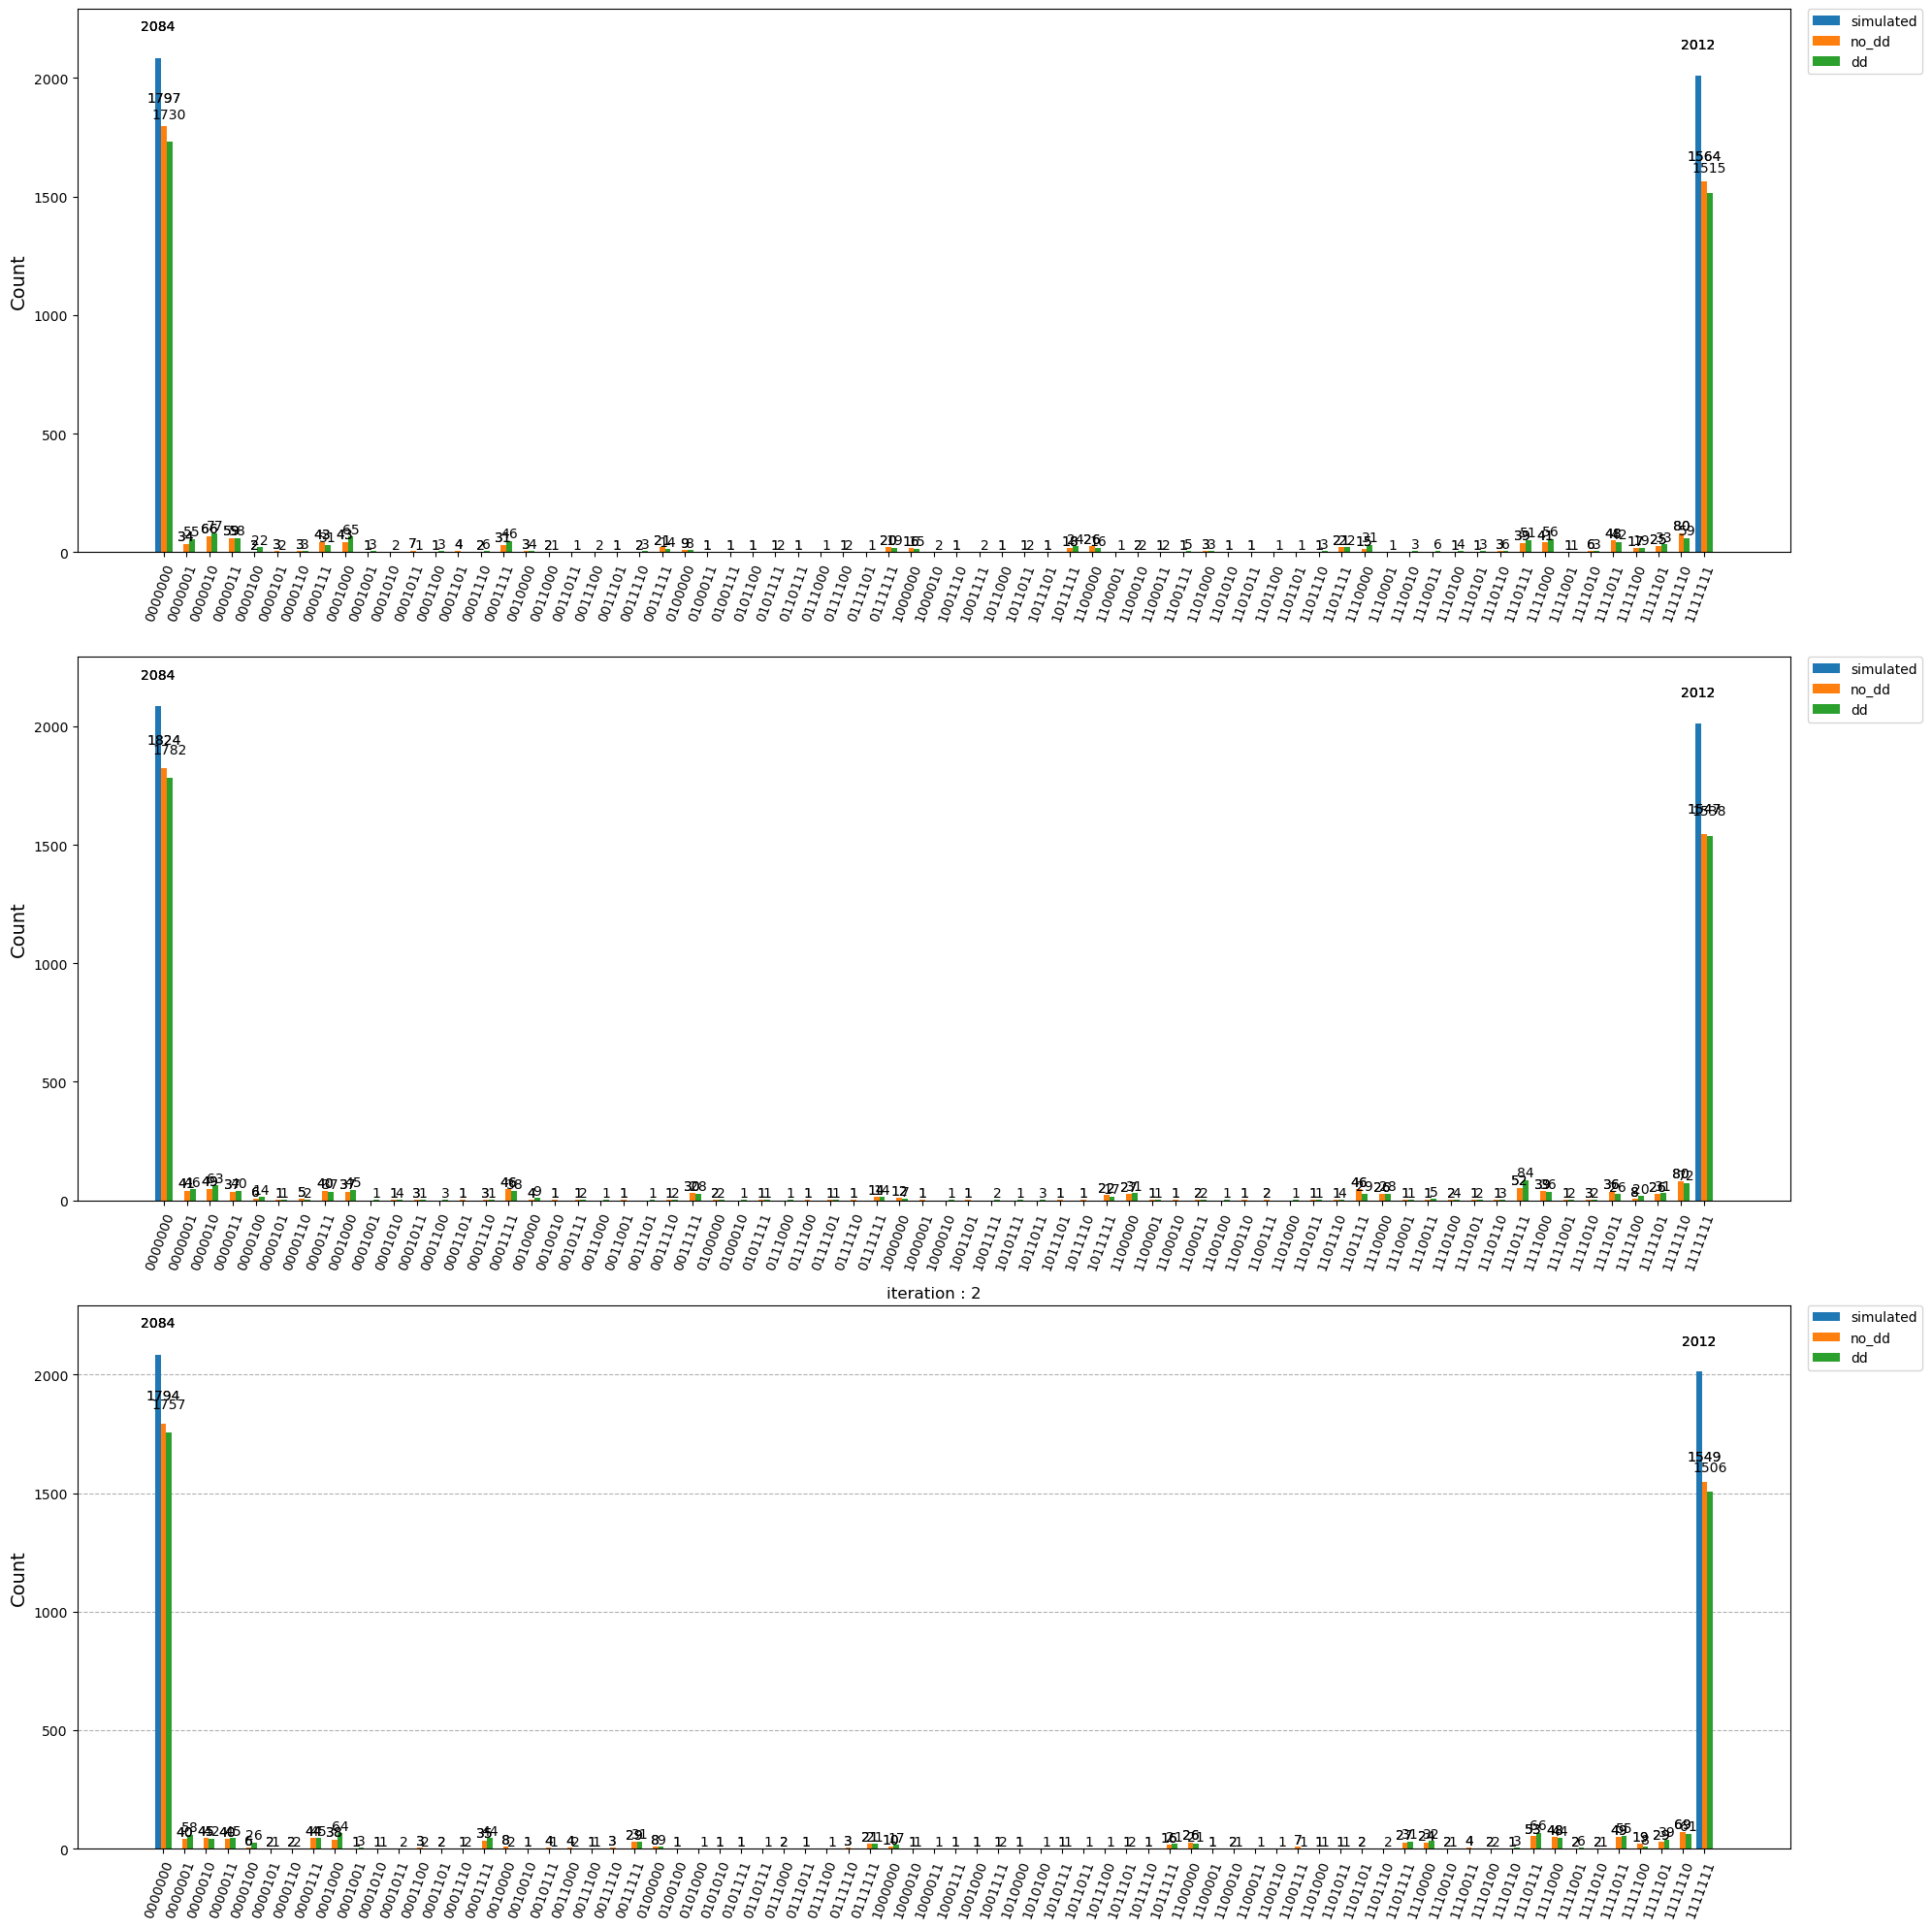

In [50]:
fig, ax = plot_all_counts(7)


In [54]:
def view_results_and_convert_in_array(qubit):
    iter_dict = {0:qubit - 7, 1:qubit - 7+4, 2:qubit - 7+8}

    simulated_data = []
    no_dd_data = []
    dd_data = []
    alt_no_dd_data = []
    alt_dd_data = []

    for i in iter_dict:
        hf = df.iloc[iter_dict[i], 8]
        alt_hf = df.iloc[iter_dict[i], 9]
        print(f"For qubit: {qubit} \n Hellinger Fidelity wrt ideal (simulated, no_dd, dd):\n {hf} \n Hellinger Fidelity wrt simulated (no_dd, dd):\n {alt_hf} \n")
        
        simulated_data.append(hf[0])

        simulated_data.append(hf[0])
        no_dd_data.append(hf[1])
        dd_data.append(hf[2])
        alt_no_dd_data.append(alt_hf[0])
        alt_dd_data.append(alt_hf[1])    

    return [simulated_data, no_dd_data, dd_data, alt_no_dd_data, alt_dd_data]



### Parse the results for plot

In [55]:
view_results_and_convert_in_array(7)

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999227464122543, 0.8195695747736642, 0.7913659265154455] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8200063000983601, 0.7917661978506112] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999227464122543, 0.821606442405718, 0.8094508782487749] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8221374553844653, 0.8099119971337146] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999227464122543, 0.81506472142881, 0.7954506629151301] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8155275524989095, 0.7959278902421464] 



[[0.9999227464122543,
  0.9999227464122543,
  0.9999227464122543,
  0.9999227464122543,
  0.9999227464122543,
  0.9999227464122543],
 [0.8195695747736642, 0.821606442405718, 0.81506472142881],
 [0.7913659265154455, 0.8094508782487749, 0.7954506629151301],
 [0.8200063000983601, 0.8221374553844653, 0.8155275524989095],
 [0.7917661978506112, 0.8099119971337146, 0.7959278902421464]]

In [56]:

data7  = view_results_and_convert_in_array(7)[1:3]
data8  = view_results_and_convert_in_array(8)[1:3]
data9  = view_results_and_convert_in_array(9)[1:3]
data10 = view_results_and_convert_in_array(10)[1:3]


For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999227464122543, 0.8195695747736642, 0.7913659265154455] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8200063000983601, 0.7917661978506112] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999227464122543, 0.821606442405718, 0.8094508782487749] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8221374553844653, 0.8099119971337146] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999227464122543, 0.81506472142881, 0.7954506629151301] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8155275524989095, 0.7959278902421464] 

For qubit: 8 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999310922823661, 0.7708756531076357, 0.7176416047666205] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7700506086115755, 0.7167837848960789] 

For qubit: 8 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [0.9999310922823661, 0.7863260681767733, 0.727

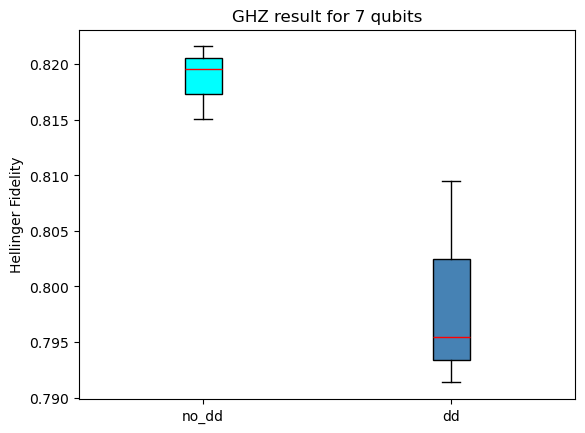

In [32]:
## For 7 Qubits

labels = ['no_dd', 'dd']
colors = ['cyan', 'steelblue']

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 7 qubits")

bplot = ax.boxplot(data7,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

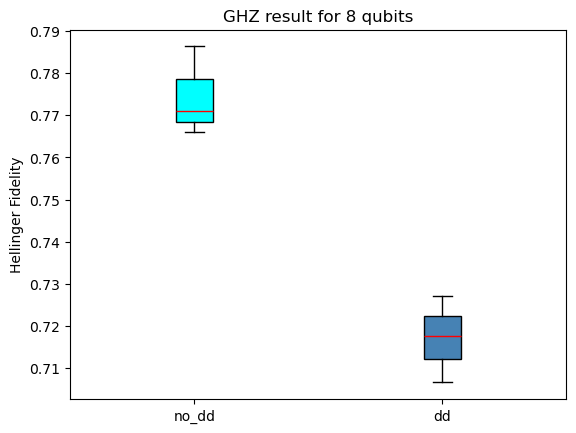

In [33]:
## For 8 Qubits

labels = ['no_dd', 'dd']
colors = ['cyan', 'steelblue']

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 8 qubits")

bplot = ax.boxplot(data8,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

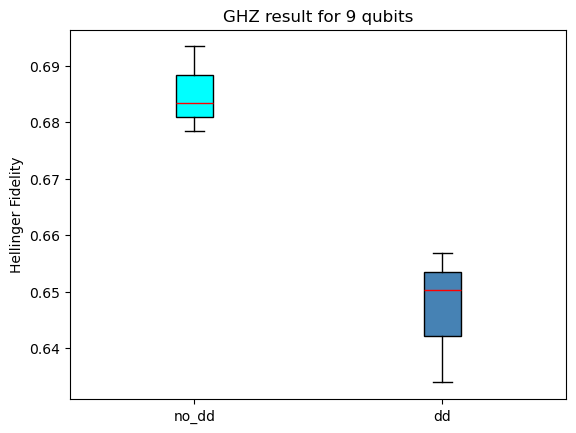

In [34]:
## For 9 Qubits

labels = ['no_dd', 'dd']
colors = ['cyan', 'steelblue']

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 9 qubits")

bplot = ax.boxplot(data9,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

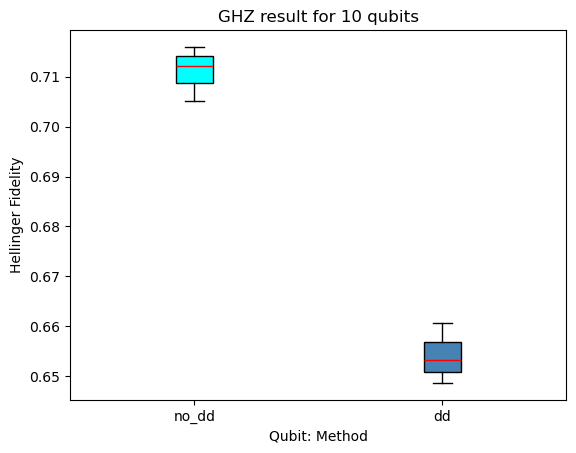

In [ ]:
## For 10 Qubits

labels = ['no_dd', 'dd']
colors = ['cyan', 'steelblue']

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 10 qubits")

bplot = ax.boxplot(data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


plt.show()

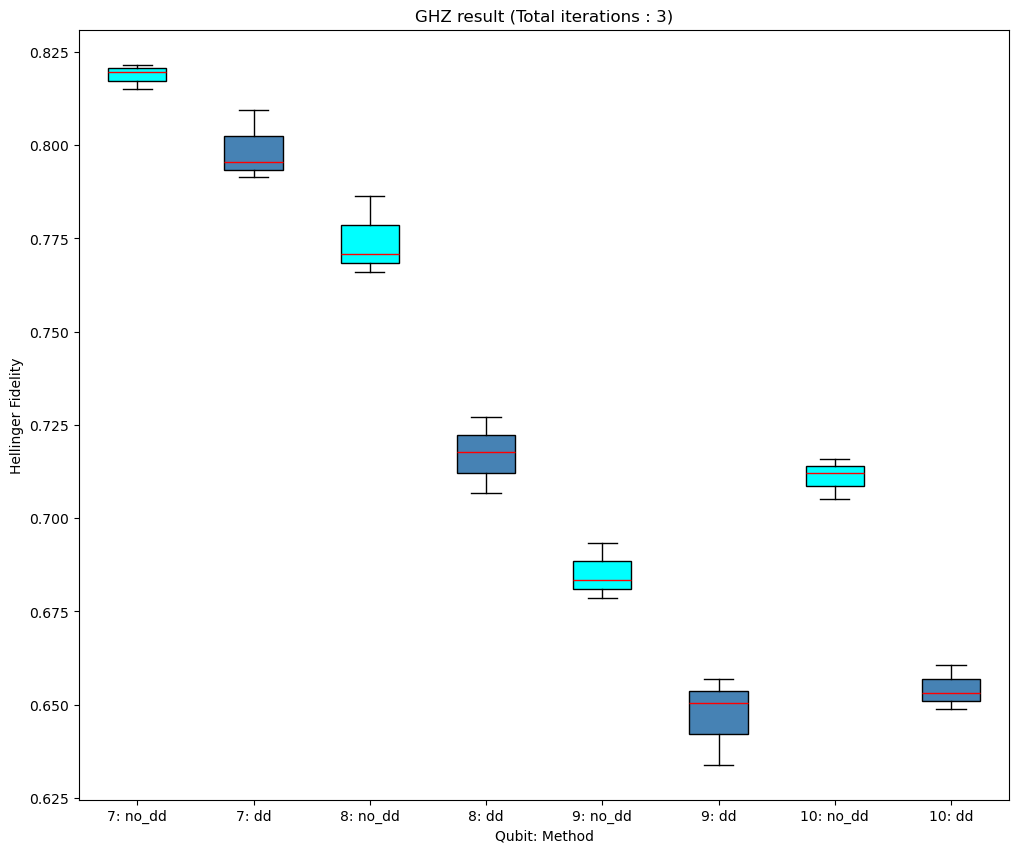

In [63]:
labels = ['7: no_dd', '7: dd', '8: no_dd', '8: dd', '9: no_dd', '9: dd', '10: no_dd', '10: dd']
colors = ['cyan', 'steelblue', 'cyan', 'steelblue', 'cyan', 'steelblue', 'cyan', 'steelblue']

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result (Total iterations : 3)")

bplot = ax.boxplot(data7+data8+data9+data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Qubit: Method")

plt.show()